# Block Order LMMs & other plots

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import PathPatch, Patch
from matplotlib.lines import Line2D

import seaborn as sns
from pathlib import Path
import re

import statsmodels.formula.api as smf
from scipy.stats import chi2
from statsmodels.stats.anova import AnovaRM

In [2]:
IBM_COLORBLIND = [
    "#ffb000",  # yellow
    "#fe6100",  # orange
    "#dc267f",  # pink
    "#785ef0",  # purple
    "#648fff",  # blue
]
IBM_COLORS = [
    "#6929c4",  # Purple 70
    "#1192e8",  # Cyan 50
    "#005d5d",  # Teal 70
    "#9f1853",  # Magenta 70
    "#fa4d56",  # Red 50
    "#570408",  # Red 90
    "#198038",  # Green 60
    "#002d9c",  # Blue 80
    "#ee538b",  # Magenta 50
    "#b28600",  # Yellow 50
    "#009d9a",  # Teal 50
    "#012749",  # Cyan 90
    "#8a3800",  # Orange 70
    "#a56eff",  # Purple 50
]
IBM_LIGHT = [
    "#8a3ffc",  # Purple 60
    "#33b1ff",  # Cyan 40
    "#007d79",  # Teal 60
    "#ff7eb6",  # Magenta 40
    "#fa4d56",  # Red 50
    "#fff1f1",  # Red 10 (very light)
    "#6fdc8c",  # Green 30
    "#4589ff",  # Blue 50
    "#d12771",  # Magenta 60
    "#d2a106",  # Yellow 40
    "#08bdba",  # Teal 40
    "#bae6ff",  # Cyan 20 (very light)
    "#ba4e00",  # Orange 60
    "#d4bbff",  # Purple 30 (very light)
]

CONDS = {"Nelo": "Baseline",
        "Coda": "Proactive",
        "Lumo": "Optional"}


CONDITIONS   = ["Optional", "Proactive", "Baseline"]
DVS          = ["trust", "understanding", "nasa"]
DV_LABELS    = {"trust": "Trust", "understanding": "System Understanding", "nasa": "Mental Workload"}
BLOCKS       = [1, 2, 3]
ALPHA_BONF   = 0.05 / 3
SUBJECT_COL  = "participant_id"

COLORS = {
    "Optional": "#6929c4",
    "Proactive": "#1192e8",
    "Baseline": "#005d5d",
}

sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'sans-serif'


In [ ]:
merged = pd.read_csv("../DATA/merged.csv")
demo = pd.read_csv("../DATA/demo.csv")

merged = merged[merged["block_x"] != "trial"]
df = merged.merge(demo, on="participant_id")

df["route"] = df["route"].astype("category")

df['condition'] = df['condition'].replace({
    'Nelo': 'Baseline',
    'Coda': 'Proactive',
    'Lumo': 'Optional'
})

df["condition"] = df["condition"].astype("category")

traits = [
    "tri_score",
    "nfc_score",
    "bfi_extraversion",
    "bfi_agreeableness",
    "bfi_conscientiousness",
    "bfi_neuroticism",
    "bfi_openness"
]


for trait in traits:
    df[f"{trait}_c"] = df[trait] - df[trait].mean()


outcomes = ["trust", "understanding"]

for outcome in outcomes:
    print(f"\n===== {outcome.upper()} =====")

    for condition in df["condition"].unique():

        print(f"\n--- {condition} ---")

        subset = df[df["condition"] == condition]

        for trait in traits:

            model = smf.ols(
                f"{outcome} ~ {trait}",
                data=subset
            ).fit()

            print(
                f"{trait}: "
                f"beta={model.params.iloc[1]:.3f}, "
                f"p={model.pvalues.iloc[1]:.3f}, "
                f"R²={model.rsquared:.3f}"
            )

In [4]:
def plot_trait_with_stats(df, trait, outcome):

    conditions = df["condition"].unique()

    fig, axes = plt.subplots(1, len(conditions), figsize=(18,5), sharey=True)

    for ax, condition in zip(axes, conditions):

        subset = df[df["condition"] == condition]

        sns.regplot(
            data=subset,
            x=trait,
            y=outcome,
            ax=ax,
            scatter_kws={"alpha":0.7, "color":"#ff7eb6", "edgecolor":"#740937"},
            line_kws={"linewidth":2},
            color="#1192e8",
        )

        ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

        # Fit regression model
        model = smf.ols(f"{outcome} ~ {trait}", data=subset).fit()

        beta = model.params[trait]
        intercept = model.params["Intercept"]
        p = model.pvalues[trait]
        r2 = model.rsquared

        p_text = f"$p = {p:.3f}$" if p >= 0.05 else f"$p = \\mathbf{{.{int(p*1000):03d}}}$"

        annotation = (
            f"y = ${beta:.2f}x + {intercept:.2f}$\n"
            f"{p_text}\n"
            f"$R² = {r2:.2f}$"
        )

        color = "#a7f0ba" if p < 0.05 else "lightgray"

        ax.text(
            0.05, 0.95,
            annotation,
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='top',
            family="serif"
            #bbox=dict(boxstyle="round", facecolor=color, alpha=0.4)
        )
        ax.set_title(condition, fontsize=20, family="serif")
        ax.set_xlabel("Technology Readiness Index", fontsize=16, family="serif")
        ax.set_ylabel("Predicted Trust", fontsize=16, family="serif")


    plt.suptitle(
        #f"{outcome.title()} by {trait.replace('_',' ').title()} Across Conditions",
        "Predicted Trust by Technology Readiness Index Across Conditions",
        fontsize=20,
        family="serif",
        y=1.05
    )


    plt.tight_layout()
    plt.show()

In [5]:
#plot_trait_with_stats(df, "tri_score", "trust")

In [6]:
dependent_vars = [
    "trust",
    "understanding",
    "nasa"
]

df["run"] = df["block_x"].astype(int)

def lr_test(model_small, model_large):
    lr = 2 * (model_large.llf - model_small.llf)
    df_diff = model_large.df_modelwc - model_small.df_modelwc
    p = chi2.sf(lr, df_diff)
    return lr, df_diff, p


for dv in dependent_vars:

    print("=" * 80)
    print(f"DEPENDENT VARIABLE: {dv}")
    print("=" * 80)


    # small
    m0 = smf.mixedlm(
        f"{dv} ~ condition",
        data=df,
        groups=df["participant_id"]
    ).fit(reml=False)

    # main
    m1 = smf.mixedlm(
        f"{dv} ~ condition + run",
        data=df,
        groups=df["participant_id"]
    ).fit(reml=False)

    # interaction
    m2 = smf.mixedlm(
        f"{dv} ~ condition * run",
        data=df,
        groups=df["participant_id"]
    ).fit(reml=False)


    # likelihood ratio tests
    lr1, df1, p1 = lr_test(m0, m1)
    lr2, df2, p2 = lr_test(m1, m2)

    print("\n")
    print("----- Model comparison -----")
    print(f"Condition vs Condition + Block")
    print(f"LR = {lr1:.3f}, df = {df1}, p = {p1:.3f}")

    print(f"\nCondition + Block vs Interaction")
    print(f"LR = {lr2:.3f}, df = {df2}, p = {p2:.3f}")

    print("\n")
    print("----- Primary model -----")
    print(m1.summary())

    print("\n")
    print("----- Interaction model -----")
    print(m2.summary())

    print("\n\n")

DEPENDENT VARIABLE: trust


----- Model comparison -----
Condition vs Condition + Block
LR = 0.563, df = 1, p = 0.453

Condition + Block vs Interaction
LR = 2.329, df = 2, p = 0.312


----- Primary model -----
             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    trust   
No. Observations:     78         Method:                ML      
No. Groups:           26         Scale:                 0.1449  
Min. group size:      3          Log-Likelihood:        -47.9802
Max. group size:      3          Converged:             Yes     
Mean group size:      3.0                                       
----------------------------------------------------------------
                       Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              4.131    0.142 29.046 0.000  3.852  4.409
condition[T.Optional]  0.303    0.106  2.868 0.004  0.096  0.510
condition[T.Proactive] 0

In [ ]:
df.groupby(["run", "condition"])["trust"].mean().unstack()

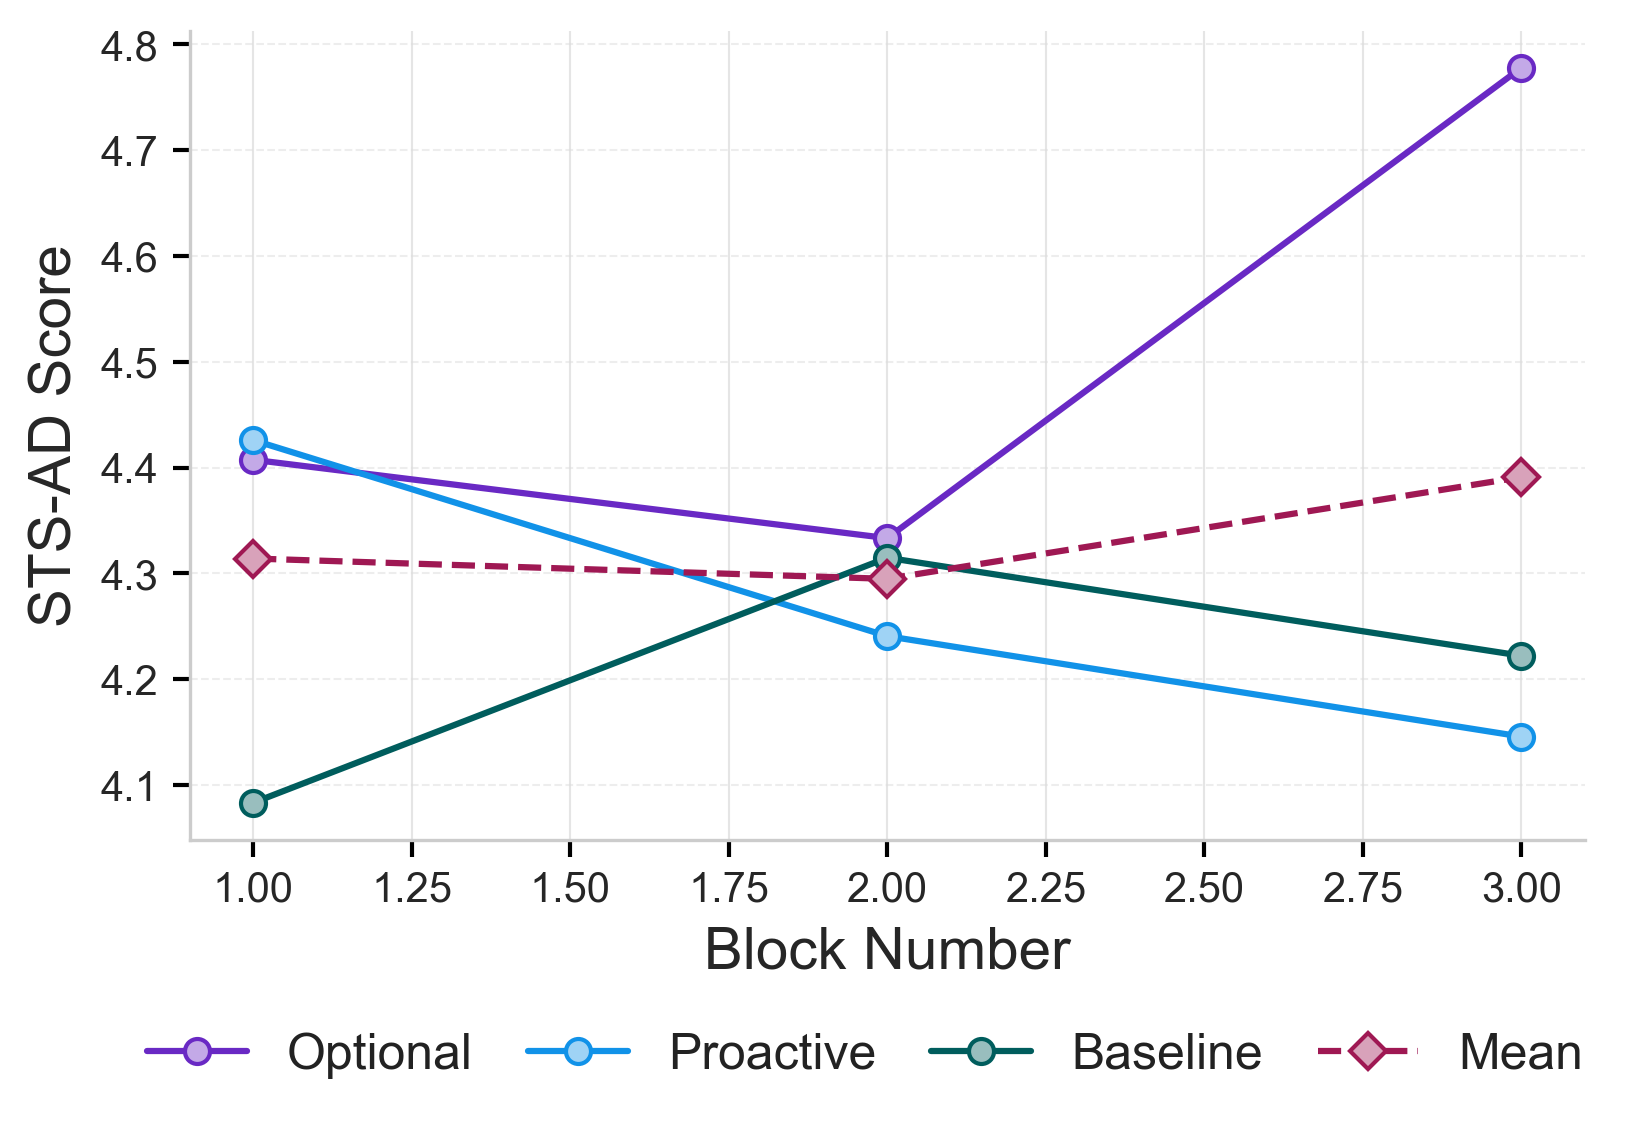

In [8]:
means = df.groupby(["run", "condition"])["trust"].mean().reset_index()
overall_mean = df.groupby("run")["trust"].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)

legend_handles = []
legend_labels = []

for condition, color in COLORS.items():
    cond_data = means[means["condition"] == condition]
    if cond_data.empty:
        continue

    line, = ax.plot(cond_data["run"],
                    cond_data["trust"],
                    color=color,
                    marker="o",
                    markeredgecolor=color,
                    markerfacecolor="white"
                    )

    top_line, = ax.plot(cond_data["run"],
                        cond_data["trust"],
                        linestyle="None",
                        color=color,
                        marker="o",
                        markeredgecolor="None",
                        markerfacecolor=to_rgba(color, alpha=0.4)
                        )

    legend_handles.append((line, top_line))
    legend_labels.append(condition)

mean_color = "#9f1853"
line_m, = ax.plot(overall_mean["run"],
                  overall_mean["trust"],
                  color=mean_color,
                  linestyle="--",
                  marker="D",
                  markeredgecolor=mean_color,
                  markerfacecolor="white"
                  )
top_line_m, = ax.plot(overall_mean["run"],
                      overall_mean["trust"],
                      linestyle="None",
                      color=mean_color,
                      marker="D",
                      markeredgecolor="None",
                      markerfacecolor=to_rgba(mean_color, alpha=0.4)
                      )

legend_handles.append((line_m, top_line_m))
legend_labels.append("Mean")


ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#ccc")
ax.spines["bottom"].set_color("#ccc")

plt.xlabel("Block Number", fontsize=14)
plt.ylabel("STS-AD Score", fontsize=14)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.tick_params(axis='x', which='both', length=4, width=1, color='black')
ax.tick_params(axis='y', which='both', length=4, width=1, color='black', direction='out', labelsize=10)

leg = fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    bbox_to_anchor=(0.5, -0.05, 0., 0.02),
    loc='upper center',
    ncols=4,
    fontsize=12,
    labelcolor="#222222",
    frameon=False,

    columnspacing=1.1,
)

plt.show()

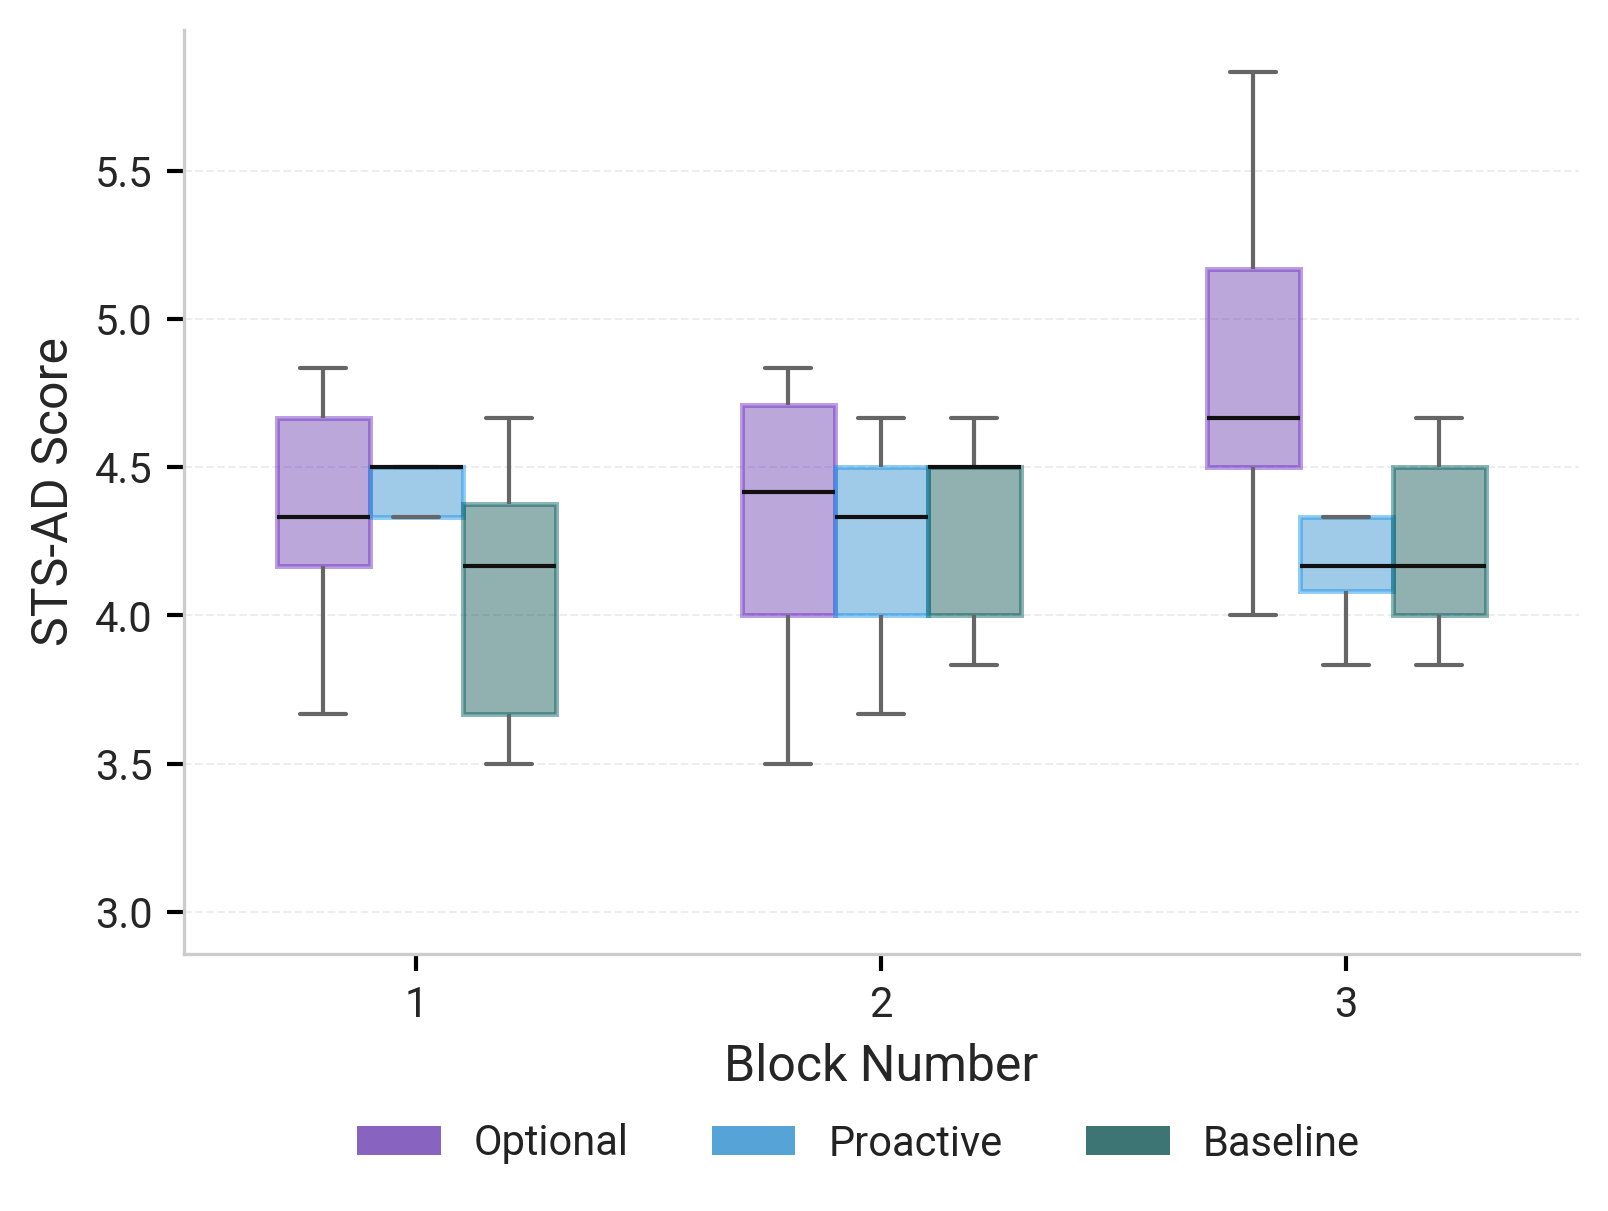

In [9]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

CONDITIONS   = ["Optional", "Proactive", "Baseline"]
DVS          = ["trust", "understanding", "nasa"]
DV_LABELS    = {"trust": "Trust", "understanding": "System Understanding", "nasa": "Mental Workload"}
BLOCKS       = [1, 2, 3]
ALPHA_BONF   = 0.05 / 3
SUBJECT_COL  = "participant_id"

COLORS = {
    "Optional": "#6929c4",
    "Proactive": "#1192e8",
    "Baseline": "#005d5d",
}

plt.rcParams['font.sans-serif'] = ['Roboto']

fig = plt.figure(figsize=(6,4), dpi=300)
ax = sns.boxplot(
        data=df,
        x='run',
        y='trust',
        hue="condition",
        hue_order=CONDITIONS,
        palette=COLORS,
        width=0.6,
        fliersize=0,
        linewidth=1,
        boxprops=dict(alpha=0.45),
        medianprops=dict(color="#111", linewidth=1),
        whiskerprops=dict(color="#666", linewidth=1),
        capprops=dict(color="#666", linewidth=1)
    )

boxes = [p for p in ax.patches if isinstance(p, PathPatch)]

for i, box in enumerate(boxes):
    condition = CONDITIONS[i // 3]
    colour = COLORS[condition]
    box.set_edgecolor(colour)
    box.set_linewidth(1.2)

# Mean line overlay
#means = df.groupby(["run", "condition"])["trust"].mean().reset_index()

#ax = sns.lineplot(
#    data=means,
#    x="run",
#    y="trust",
#    hue="condition",
#    #linestyle=":",
#    palette=COLORS,
#    alpha=0.7,
#    marker="o",
#    legend=False
#)

#for line in ax.lines:
#    color = line.get_color()
#    line.set_markeredgecolor(color)
ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#ccc")
ax.spines["bottom"].set_color("#ccc")

plt.xlabel("Block Number",fontsize=12,)
plt.ylabel("STS-AD Score",fontsize=12,)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax = plt.gca()
ax.tick_params(axis='x', which='both', length=4, width=1, color='black')
ax.tick_params(axis='y', which='both', length=4, width=1, color='black', direction='out', labelsize=10)
ax.legend().remove()
#plt.title("Trust across runs (boxplots + means)")    bbox_to_anchor=(0.5, -0.05),
#(0., 1.02, 1., -.102)   above

leg = fig.legend(bbox_to_anchor=(0.5, -0.05, 0., 0.05), loc='upper center', ncols=3,
    labelcolor="#222222", frameon=False)
for handle in leg.legend_handles:
    handle.set_edgecolor('none')
    handle.set_alpha(0.8)
plt.show()

C:\Users\celin\AppData\Local\Temp\ipykernel_9236\2780863188.py:124: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 4
  leg = fig.legend(


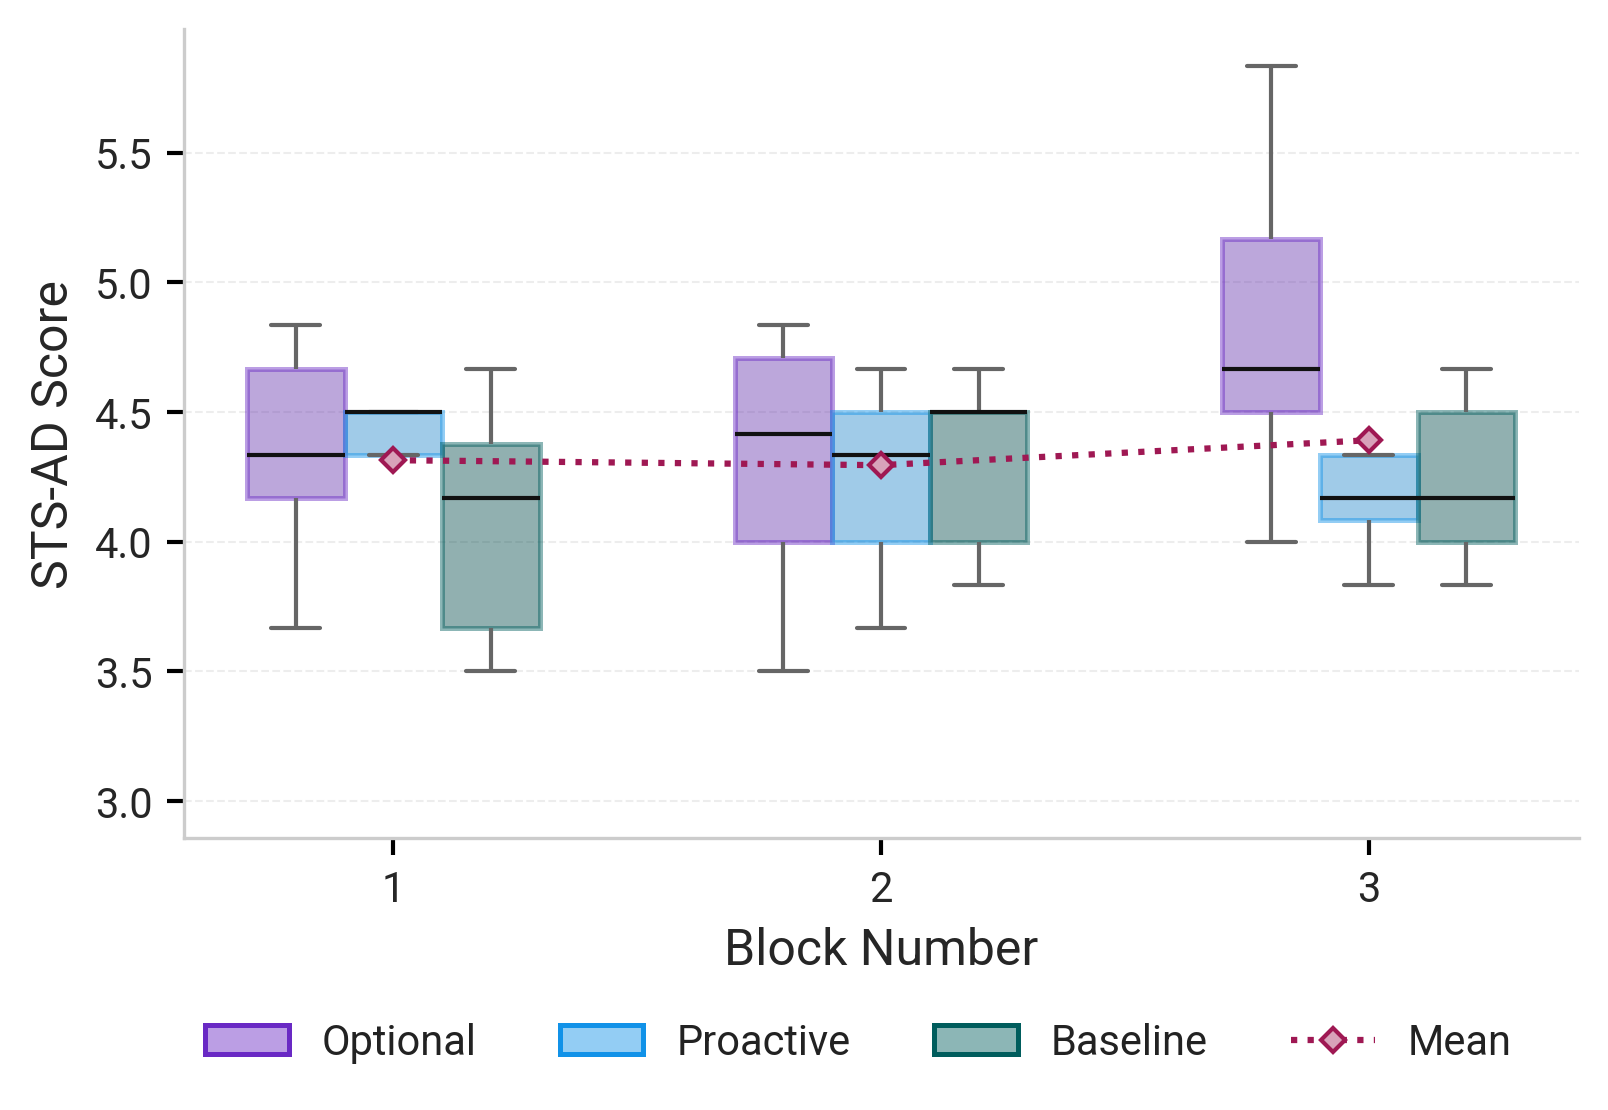

In [24]:
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Roboto']

CONDITIONS   = ["Optional", "Proactive", "Baseline"]
DVS          = ["trust", "understanding", "nasa"]
DV_LABELS    = {"trust": "Trust", "understanding": "System Understanding", "nasa": "Mental Workload"}
BLOCKS       = [1, 2, 3]
ALPHA_BONF   = 0.05 / 3
SUBJECT_COL  = "participant_id"

COLORS = {
    "Optional": "#6929c4",
    "Proactive": "#1192e8",
    "Baseline": "#005d5d",
}


overall_mean = (
    df.groupby("run", as_index=False)["trust"]
      .mean()
)

fig = plt.figure(figsize=(6, 3.5), dpi=300)
ax = sns.boxplot(
        data=df,
        x='run',
        y='trust',
        hue="condition",
        hue_order=CONDITIONS,
        palette=COLORS,
        width=0.6,
        fliersize=0,
        linewidth=1,
        boxprops=dict(alpha=0.45),
        medianprops=dict(color="#111", linewidth=1),
        whiskerprops=dict(color="#666", linewidth=1),
        capprops=dict(color="#666", linewidth=1)
    )


boxes = [p for p in ax.patches if isinstance(p, PathPatch)]
for i, box in enumerate(boxes):
    condition = CONDITIONS[i // 3]
    colour = COLORS[condition]
    box.set_edgecolor(colour)
    box.set_linewidth(1.2)

legend_handles = []
for condition in CONDITIONS:
    color = COLORS[condition]

    handle = Patch(
        facecolor=to_rgba(color, alpha=0.45),
        edgecolor=color,
        linewidth=1.2
    )
    legend_handles.append(handle)

ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#ccc")
ax.spines["bottom"].set_color("#ccc")

plt.xlabel("Block Number", fontsize=12)
plt.ylabel("STS-AD Score", fontsize=12)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax = plt.gca()
ax.tick_params(axis='x', which='both', length=4, width=1, color='black')
ax.tick_params(axis='y', which='both', length=4, width=1, color='black', direction='out', labelsize=10)

ax.legend().remove()


mean_color = "#9f1853"

line_m, = ax.plot(
    overall_mean["run"] - 1,
    overall_mean["trust"],
    color=mean_color,
    linestyle=":",
    marker="D",
    markersize=4,
    markerfacecolor="white",
    markeredgecolor=mean_color,
    linewidth=1.5,
    zorder=5
)

top_line_m, = ax.plot(
    overall_mean["run"] - 1,
    overall_mean["trust"],
    linestyle="None",
    marker="D",
    markersize=4,
    markerfacecolor=to_rgba(mean_color, alpha=0.4),
    markeredgecolor="None",
    zorder=6
)

legend_handles.append((line_m, top_line_m))
legend_labels.append("Mean")




legend_handles.append(
    Line2D(
        [0], [0],
        color=mean_color,
        linestyle="--",
        marker="D",
        markerfacecolor="white",
        markeredgecolor=mean_color,
        linewidth=1.5,
        label="Mean"
    )
)

leg = fig.legend(
    handles=legend_handles,
    labels=CONDITIONS + ["Mean"],
    bbox_to_anchor=(0.5, -0.05, 0., 0.02),
    loc='upper center',
    ncols=4,
    labelcolor="#222222",
    fontsize=10,
    frameon=False
)

plt.show()


In [11]:
model = smf.mixedlm(
    "trust ~ condition * block_x",
    data=df,
    groups=df["participant_id"]
)

result = model.fit()

print(result.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         trust   
No. Observations:         78              Method:                     REML    
No. Groups:               26              Scale:                      0.1612  
Min. group size:          3               Log-Likelihood:             -54.3250
Max. group size:          3               Converged:                  Yes     
Mean group size:          3.0                                                 
------------------------------------------------------------------------------
                                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                            4.083    0.170 23.975 0.000  3.750  4.417
condition[T.Optional]                0.324    0.234  1.384 0.166 -0.135  0.783
condition[T.Proactive]               0.343    0.234  1.464 0.143 -0.116  

In [12]:
model = smf.mixedlm(
    "trust ~ condition + block_x",
    data=df,
    groups=df["participant_id"]
)

result = model.fit()
print(result.summary())

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    trust   
No. Observations:      78         Method:                REML    
No. Groups:            26         Scale:                 0.1561  
Min. group size:       3          Log-Likelihood:        -55.1103
Max. group size:       3          Converged:             Yes     
Mean group size:       3.0                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               4.187    0.116 36.117 0.000  3.959  4.414
condition[T.Optional]   0.301    0.110  2.744 0.006  0.086  0.516
condition[T.Proactive]  0.067    0.110  0.612 0.540 -0.148  0.282
block_x[T.2]           -0.008    0.110 -0.070 0.944 -0.223  0.207
block_x[T.3]            0.080    0.110  0.725 0.469 -0.135  0.294
Group Var               

In [13]:
model0 = smf.mixedlm(
    "trust ~ condition",
    data=df,
    groups=df["participant_id"]
).fit(reml=False)

model1 = smf.mixedlm(
    "trust ~ condition + block_x",
    data=df,
    groups=df["participant_id"]
).fit(reml=False)

In [14]:
lr = 2 * (model1.llf - model0.llf)
df_diff = model1.df_modelwc - model0.df_modelwc
p = chi2.sf(lr, df_diff)

print(lr, df_diff, p)

0.8324507153287186 2 0.6595316232294368


In [15]:
model0 = smf.mixedlm(
    "trust ~ condition",
    data=df,
    groups=df["participant_id"]
)

result0 = model0.fit()

In [16]:
lr = 2 * (result.llf - result0.llf)
df_diff = result.df_modelwc - result0.df_modelwc
p = chi2.sf(lr, df_diff)

print(f"LR = {lr:.3f}, df = {df_diff}, p = {p:.3f}")

LR = -4.693, df = 2, p = 1.000


In [17]:
def print_json_structure():

    DATA_FOLDER = "trimmed_data"

    VIDEO_PATTERN = re.compile(r"varjo_capture_(.+?)_trimmed\.mp4$")
    GAZE_PATTERN = re.compile(r"varjo_gaze_output_(.+?)_trimmed\.csv$")

    participants = []

    root = Path(DATA_FOLDER)

    for participant_dir in sorted(root.iterdir(), key=lambda p: int(p.name)):
        if not participant_dir.is_dir():
            continue

        participant_id = f"P{int(participant_dir.name):02d}"

        video_files = sorted(participant_dir.glob("varjo_capture_*_trimmed.mp4"))

        videos = []

        for block_idx, video_file in enumerate(video_files):
            match = VIDEO_PATTERN.match(video_file.name)

            if not match:
                continue

            timestamp = match.group(1)

            gaze_file = participant_dir / f"varjo_gaze_output_{timestamp}_trimmed.csv"

            if not gaze_file.exists():
                print(f"Missing gaze file for: {video_file.name}")
                continue

            videos.append({
                "block": str(block_idx),
                "video": f'{{DATA_FOLDER}}/{participant_dir.name}/{video_file.name}',
                "gaze": f'{{DATA_FOLDER}}/{participant_dir.name}/{gaze_file.name}',
            })

        participants.append({
            "id": participant_id,
            "videos": videos
        })

    print("PARTICIPANTS = [")

    for participant in participants:
        print("    {")
        print(f'        "id": "{participant["id"]}",')
        print('        "videos": [')

        for video in participant["videos"]:
            print(
                f'            {{"block": "{video["block"]}", '
                f'"video": f"{video["video"]}", '
                f'"gaze": f"{video["gaze"]}"}},'
            )

        print("        ]")
        print("    },")

    print("]")

In [ ]:
all_results = []

for outcome in outcomes:

    for trait in traits:

        centered_trait = f"{trait}_c"

        formula = f"{outcome} ~ condition * {centered_trait} + route"

        model = smf.mixedlm(
            formula,
            data=df,
            groups=df["participant_id"]
        )

        result = model.fit()

        for predictor in result.params.index:

            if predictor == "Group Var":
                continue

            all_results.append({
                "Outcome": outcome,
                "Trait": trait,
                "Predictor": predictor,
                "Beta": round(result.params[predictor], 3),
                "SE": round(result.bse[predictor], 3),
                "p": round(result.pvalues[predictor], 4),
                "Significant": "Yes" if result.pvalues[predictor] < .05 else "No"
            })

results_df = pd.DataFrame(all_results)

# sort by p value
results_df = results_df.sort_values(by=["Outcome", "p"])

print(results_df)

In [ ]:
sig_results = results_df[results_df["p"] < .05]

print(sig_results)

In [ ]:
all_results = []

for outcome in outcomes:

    predictors = " + ".join([f"{trait}_c" for trait in traits])

    #formula = f"{outcome} ~ condition + route + {predictors}"
    formula = """
    trust ~ condition * bfi_openness_c
            + route
            + tri_score_c + nfc_score_c
            + bfi_extraversion_c + bfi_agreeableness_c
            + bfi_conscientiousness_c + bfi_neuroticism_c
    """
    model = smf.mixedlm(
        formula,
        data=df,
        groups=df["participant_id"]
    )

    result = model.fit()

    for predictor in result.params.index:

        if predictor == "Group Var":
            continue

        all_results.append({
            "Outcome": outcome,
            "Predictor": predictor,
            "Beta": round(result.params[predictor], 3),
            "SE": round(result.bse[predictor], 3),
            "p": round(result.pvalues[predictor], 4),
            "Significant": "Yes" if result.pvalues[predictor] < .05 else "No"
        })


results_df = pd.DataFrame(all_results)

# Sort by p value
results_df = results_df.sort_values(by=["Outcome", "p"])

print(results_df)

In [ ]:
sig_results = results_df[results_df["p"] < .05]

print(sig_results)

In [ ]:
op_sd = df["bfi_openness_c"].std()
op_levels = np.array([-op_sd, 0, op_sd])

conditions = df["condition"].cat.categories

pred_data = pd.DataFrame({
    "bfi_openness_c": np.tile(op_levels, len(conditions)),
    "condition": np.repeat(conditions, len(op_levels)),
    "route": df["route"].mode()[0]
})

#other traits to 0 (centred)
for trait in [
    "tri_score_c", "nfc_score_c", "bfi_extraversion_c",
    "bfi_agreeableness_c", "bfi_conscientiousness_c",
    "bfi_neuroticism_c"
]:
    pred_data[trait] = 0

# Predict
pred_data["trust_pred"] = result.predict(pred_data)


plt.figure(figsize=(6.5, 4.5), dpi=300)

x_labels = ["-1 SD", "Mean", "+1 SD"]


line_styles = ["-", "--", "-."]
markers = ["o", "s", "^"]
colours = ["#6929c4","#1192e8","#005d5d"]


for i, cond in enumerate(conditions):
    subset = pred_data[pred_data["condition"] == cond]

    plt.plot(
        x_labels,
        subset["trust_pred"],
        linestyle=line_styles[i % len(line_styles)],
        marker=markers[i % len(markers)],
        linewidth=1.8,
        markersize=6,
        color=colours[i],
        label=CONDS[cond],
    )

plt.xlabel("Openness (±1 SD)", fontsize=12, family="serif")
plt.ylabel("Predicted Trust", fontsize=12, family="serif")
plt.title("Interaction between Condition and Openness on Trust", fontsize=12, family="serif")

plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Condition", frameon=False, prop = {'family': "serif"})
plt.rcParams['font.family'] = 'serif'
plt.tight_layout()
plt.show()

In [ ]:
anova_df = df[["participant_id", "condition", "trust"]].dropna()

anova = AnovaRM(
    data=anova_df,
    depvar="trust",
    subject="participant_id",
    within=["condition"]
).fit()
#6929c4
#1192e8
#005d5d
print(anova)

In [ ]:
plt.figure(figsize=(6, 4.5), dpi=300)

ax = sns.histplot(
    df['tri_score'],
    kde=True,
    color="#1192e8",
    bins=10
)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9
        )


plt.xlabel("TRI score")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

In [ ]:
median_tri = df['tri_score'].median()
print(median_tri)
df['tri_group'] = df['tri_score'].apply(
    lambda x: 'Low TRI' if x <= 3.5 else 'High TRI'
)

print(df['tri_group'].value_counts())

In [ ]:
plt.figure(figsize=(7, 5), dpi=300)

order=["Lumo", "Coda", "Nelo"]

ax = sns.boxplot(
    data=df,
    x='condition',
    y='trust',
    hue='tri_group',
    palette=IBM_LIGHT,
    order=order
)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
sns.stripplot(
    data=df,
    x='condition',
    y='trust',
    hue='tri_group',
    dodge=True,
    alpha=0.4,
    color="black",
    order=order,
    legend=False,
)

plt.legend(title="TRI Group")
ax = plt.gca()
ax.set_xticklabels([CONDS[o] for o in order])
plt.show()


In [ ]:
g = sns.catplot(
    data=df,
    x='condition',
    y='trust',
    col='tri_group',
    kind='box',
    palette=IBM_LIGHT,
    height=4,
    aspect=0.9,
    sharey=True,
    order=order
)

g.set_titles("")

from statannotations.Annotator import Annotator

pairs = [("Lumo", "Nelo")]

for ax, group in zip(g.axes.flat, df['tri_group'].unique()):
    sub = df[df['tri_group'] == group]

    annotator = Annotator(
        ax,
        pairs,
        data=sub,
        x='condition',
        y='trust',
        order=["Lumo", "Coda", "Nelo"]
    )

    annotator.configure(
        test='t-test_paired',
        text_format='star',
        loc='outside'
    )

    annotator.apply_and_annotate()
for ax, group in zip(g.axes.flat, df['tri_group'].unique()):
    ax.text(
        0.5, -0.25,  # x=center, y=below axis
        group,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=12
    )
ax = plt.gca()
ax.set_xticklabels([CONDS[o] for o in order])
plt.show()

In [ ]:
from scipy.stats import ttest_rel

results = {}

for group in df['tri_group'].unique():
    sub = df[df['tri_group'] == group]

    # pivot for paired test
    pivot = sub.pivot(index='participant_id', columns='condition', values='trust')

    stat, p = ttest_rel(pivot['Lumo'], pivot['Nelo'])
    results[group] = (stat, p)

print(results)

In [ ]:
bfi_cols = [
    "bfi_extraversion",
    "bfi_agreeableness",
    "bfi_conscientiousness",
    "bfi_neuroticism",
    "bfi_openness"
]

df_bfi = df.melt(
    value_vars=bfi_cols,
    var_name="trait",
    value_name="score"
)

g = sns.FacetGrid(df_bfi, col="trait", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "score", kde=True, color="#1192e8")
g.map_dataframe(
    lambda data, color: plt.axvline(
        data["score"].median(),
        color="red",
        linestyle="--"
    )
)
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
median_n = df['bfi_neuroticism'].median()
print(median_n)
df['neuro_group'] = df['bfi_neuroticism'].apply(
    lambda x: 'Low NEURO' if x <= 3.5 else 'High NEURO'
)

print(df['neuro_group'].value_counts())


plt.figure(figsize=(7, 5), dpi=300)

order=["Lumo", "Coda", "Nelo"]

ax = sns.boxplot(
    data=df,
    x='condition',
    y='trust',
    hue='tri_group',
    palette=IBM_LIGHT,
    order=order
)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
sns.stripplot(
    data=df,
    x='condition',
    y='trust',
    hue='tri_group',
    dodge=True,
    alpha=0.4,
    color="black",
    order=order,
    legend=False,
)

plt.legend(title="NEU Group")
ax = plt.gca()
ax.set_xticklabels([CONDS[o] for o in order])
plt.show()

In [ ]:
g = sns.catplot(
    data=df,
    x='condition',
    y='trust',
    col='tri_group',
    kind='box',
    palette=IBM_LIGHT,
    height=4,
    aspect=0.9,
    sharey=True,
    order=order
)

g.set_titles("")

from statannotations.Annotator import Annotator

pairs = [("Lumo", "Nelo"), ("Lumo", "Coda")]

for ax, group in zip(g.axes.flat, df['tri_group'].unique()):
    sub = df[df['tri_group'] == group]

    annotator = Annotator(
        ax,
        pairs,
        data=sub,
        x='condition',
        y='trust',
        order=["Lumo", "Coda", "Nelo"]
    )

    annotator.configure(
        test='t-test_paired',
        text_format='star',
        loc='outside'
    )

    annotator.apply_and_annotate()
for ax, group in zip(g.axes.flat, df['tri_group'].unique()):
    ax.text(
        0.5, -0.25,  # x=center, y=below axis
        group,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=12
    )
ax = plt.gca()
ax.set_xticklabels([CONDS[o] for o in order])
plt.show()